# CSE-CIC-IDS2018 — Compare All Models

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies, no zip/download
steps. Model list is discovered automatically from whatever `*_metrics.csv` files exist under
`Results/Models/`, so this notebook adapts to however many / whichever models
`04_Model_Training_Optuna.ipynb` produced — no hardcoded model names.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH = PROJECT_PATH / "Results"
MODELS_PATH  = RESULTS_PATH / "Models"
FIGURES_PATH = RESULTS_PATH / "Figures"
TABLES_PATH  = RESULTS_PATH / "Tables"

for p in [FIGURES_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

## 2. Build the Model Comparison Table

Discovers every trained model's metrics file rather than assuming a fixed list.

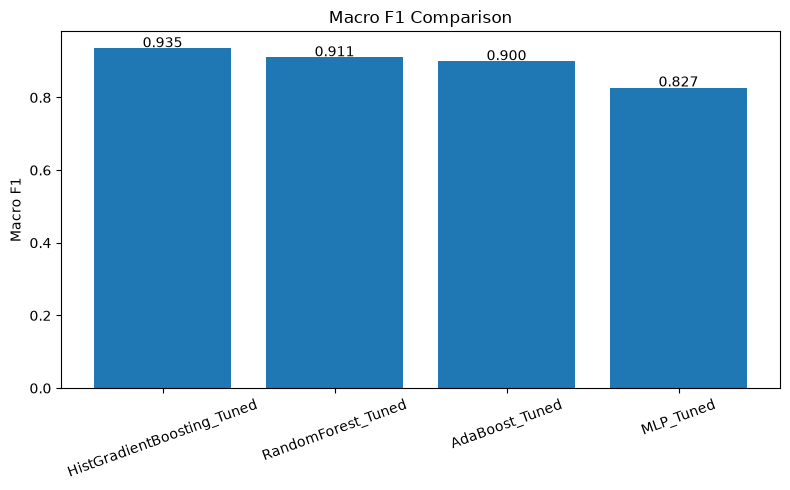

In [4]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Macro F1"])
plt.title("Macro F1 Comparison")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
for i, v in enumerate(comparison["Macro F1"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "macro_f1_comparison.png", dpi=200)
plt.show()

## 4. Precision / Recall / F1 (grouped) + Heatmap

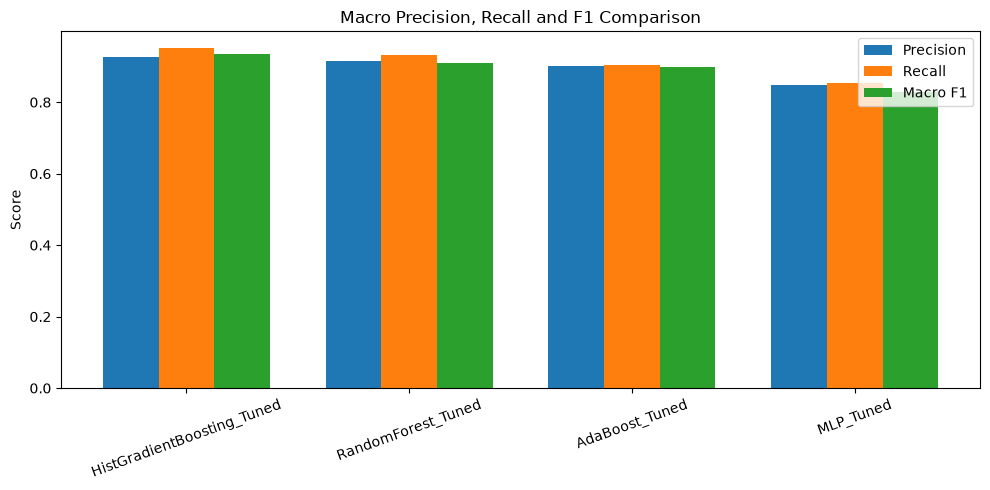

In [5]:
x = np.arange(len(comparison))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, comparison["Macro Precision"], width, label="Precision")
plt.bar(x, comparison["Macro Recall"], width, label="Recall")
plt.bar(x + width, comparison["Macro F1"], width, label="Macro F1")
plt.xticks(x, comparison["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Macro Precision, Recall and F1 Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "precision_recall_f1_comparison.png", dpi=200)
plt.show()

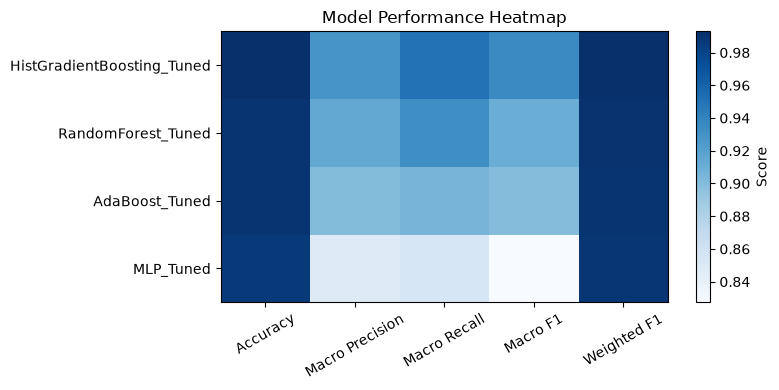

In [6]:
metrics_cols = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]
heatmap_data = comparison.set_index("Model")[metrics_cols]

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_data, aspect="auto", cmap="Blues")
plt.xticks(range(len(metrics_cols)), metrics_cols, rotation=30)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.colorbar(label="Score")
plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "performance_heatmap.png", dpi=200)
plt.show()

## 5. Class Distribution Before vs. After CTGAN

In [7]:
train_before = pd.read_parquet(PROCESSED_DATA_PATH / "train_selected.parquet")
train_after = pd.read_parquet(PROCESSED_DATA_PATH / "balanced_train_selected.parquet")

before = train_before["Label"].value_counts().sort_index()
after = train_after["Label"].value_counts().sort_index()

class_dist = pd.DataFrame({"Before CTGAN": before, "After CTGAN": after}).fillna(0)
class_dist.to_csv(TABLES_PATH / "class_distribution_before_after_CTGAN.csv")
class_dist

,Before CTGAN,After CTGAN
Label,,
0,680805,100000
1,14293,14293
2,489,10000
3,184,10000
4,33844,33844
5,1384,5536
6,29171,29171
7,2099,8396
8,22017,22017


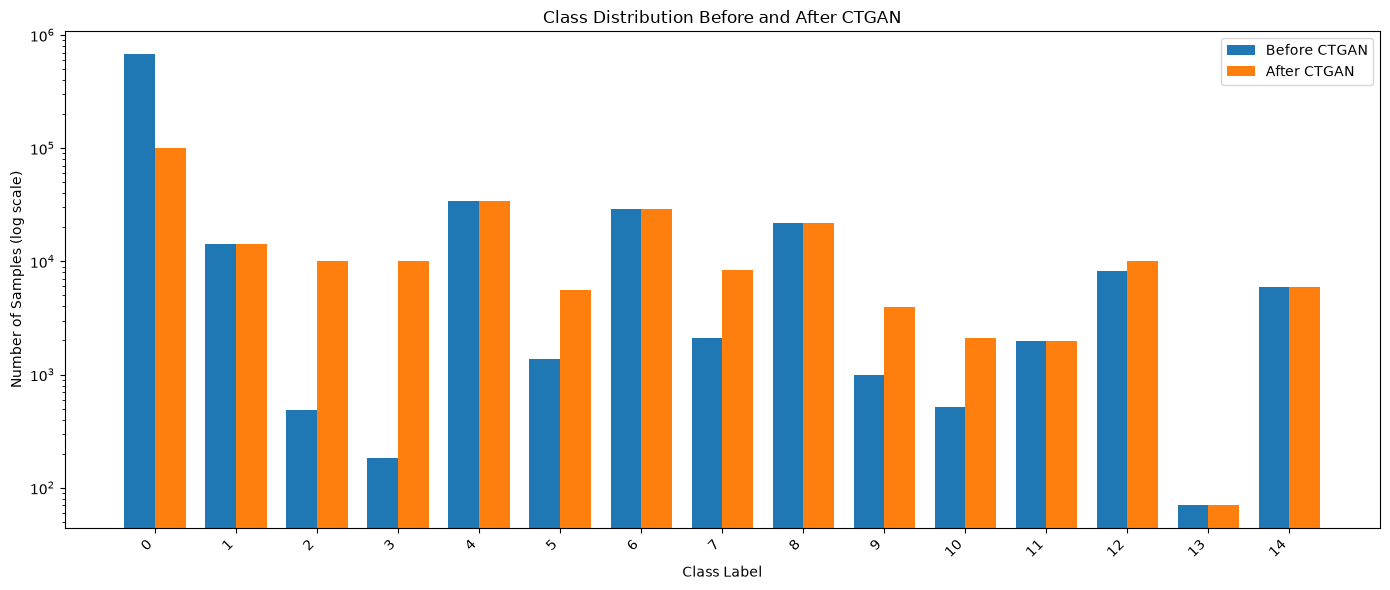

In [8]:
x = np.arange(len(class_dist))
width = 0.38

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, class_dist["Before CTGAN"], width, label="Before CTGAN")
plt.bar(x + width/2, class_dist["After CTGAN"], width, label="After CTGAN")
plt.yscale("log")
plt.xticks(x, class_dist.index, rotation=45, ha="right")
plt.ylabel("Number of Samples (log scale)")
plt.xlabel("Class Label")
plt.title("Class Distribution Before and After CTGAN")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "class_distribution_before_after_CTGAN.png", dpi=200)
plt.show()

## 6. Top Mutual Information Features

In [9]:
mi_path = TABLES_PATH / "mutual_information_scores.csv"

if mi_path.exists():
    mi = pd.read_csv(mi_path).sort_values("MI Score", ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    plt.barh(mi["Feature"][::-1], mi["MI Score"][::-1])
    plt.xlabel("Mutual Information Score")
    plt.ylabel("Feature")
    plt.title("Top 20 Features Selected by Mutual Information")
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / "top20_mutual_information.png", dpi=200)
    plt.show()
else:
    print(f"Skipped: {mi_path} not found. Run 03_Data_Preparation_for_CTGAN.ipynb first.")

Skipped: M:\IDS\c_filesnew\Results\Tables\mutual_information_scores.csv not found. Run 03_Data_Preparation_for_CTGAN.ipynb first.


In [10]:
label_mapping = pd.read_csv(PROCESSED_DATA_PATH / "label_mapping.csv")
label_to_id = dict(zip(label_mapping["Class"], label_mapping["Encoded"]))
id_to_label = dict(zip(label_mapping["Encoded"], label_mapping["Class"]))

In [11]:
# Per-class F1/Recall comparison across all trained models, focused on rare classes
RARE_CLASSES = [
    "SQL Injection", "Brute Force -XSS", "Brute Force -Web",
    "DoS attacks-Slowloris", "DoS attacks-SlowHTTPTest",
    "DDOS attack-LOIC-UDP", "DoS attacks-GoldenEye", "Infilteration",
]

report_files = sorted(MODELS_PATH.glob("*_classification_report.csv"))
print(f"Found {len(report_files)} classification reports:")
for f in report_files:
    print(" -", f.name)

per_class_f1 = {}
per_class_recall = {}

for f in report_files:
    model_name = f.stem.replace("_classification_report", "")
    report = pd.read_csv(f, index_col=0)

    # rows are class labels (as strings of the encoded id) + accuracy/macro avg/weighted avg
    report = report[report.index.isin([str(label_to_id[c]) for c in RARE_CLASSES])]
    report.index = report.index.astype(int).map(id_to_label)

    per_class_f1[model_name] = report["f1-score"]
    per_class_recall[model_name] = report["recall"]

f1_comparison = pd.DataFrame(per_class_f1).loc[RARE_CLASSES]
recall_comparison = pd.DataFrame(per_class_recall).loc[RARE_CLASSES]

f1_comparison.to_csv(TABLES_PATH / "rare_class_f1_comparison.csv")
recall_comparison.to_csv(TABLES_PATH / "rare_class_recall_comparison.csv")

print("\nF1-score on rare classes, by model:")
f1_comparison.round(3)

Found 4 classification reports:
 - AdaBoost_Tuned_classification_report.csv
 - HistGradientBoosting_Tuned_classification_report.csv
 - MLP_Tuned_classification_report.csv
 - RandomForest_Tuned_classification_report.csv

F1-score on rare classes, by model:


,AdaBoost_Tuned,HistGradientBoosting_Tuned,MLP_Tuned,RandomForest_Tuned
SQL Injection,0.733,0.824,0.435,0.778
Brute Force -XSS,0.867,0.955,0.560,0.932
Brute Force -Web,0.934,0.938,0.699,0.940
DoS attacks-Slowloris,1.000,0.996,0.981,1.000
DoS attacks-SlowHTTPTest,0.598,0.711,0.351,0.497
DDOS attack-LOIC-UDP,0.996,0.996,0.976,0.993
DoS attacks-GoldenEye,0.999,1.000,0.998,0.999
Infilteration,0.633,0.745,0.645,0.683


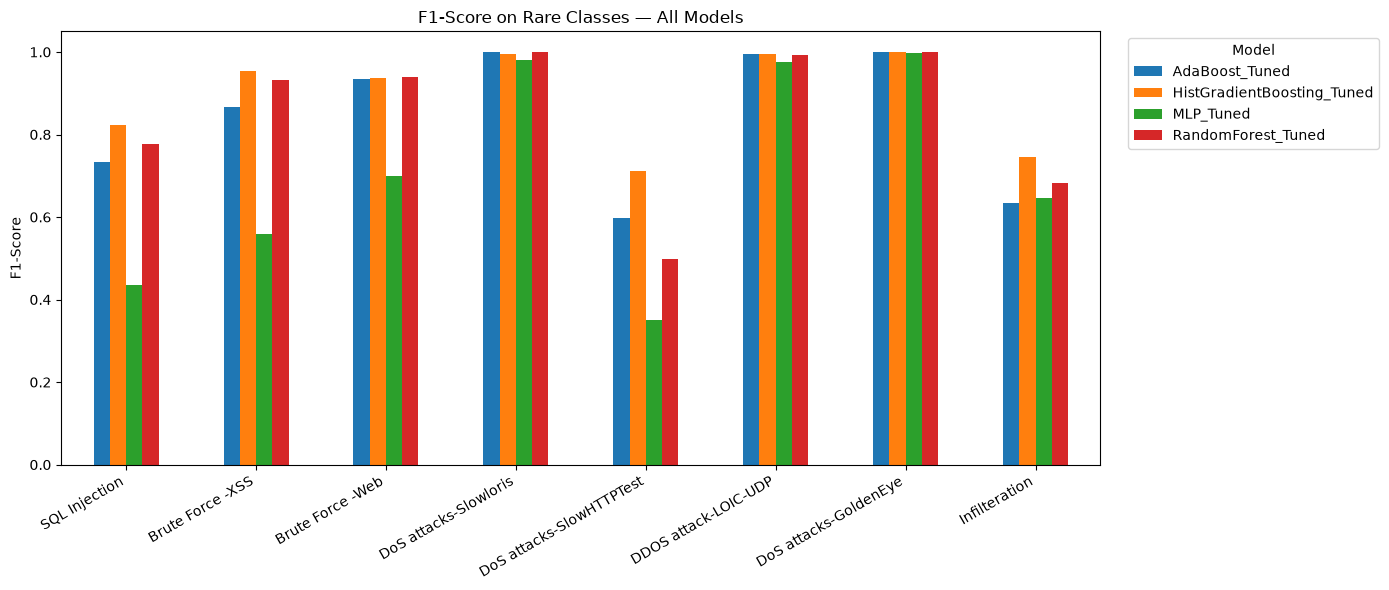

In [12]:
# Visualize it — this is the chart that'll show exactly where MLP loses ground
f1_comparison.plot(kind="bar", figsize=(14, 6))
plt.title("F1-Score on Rare Classes — All Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "rare_class_f1_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

---
**Final report artifacts (under `Results/`):**
- `Tables/model_comparison.csv`
- `Figures/accuracy_comparison.png`, `macro_f1_comparison.png`, `precision_recall_f1_comparison.png`,
  `performance_heatmap.png`, `class_distribution_before_after_CTGAN.png`, `top20_mutual_information.png`
- `Tables/class_distribution_before_after_CTGAN.csv`